# MDR-TS v22.3
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v22.3
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/derived_8.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

- Reviewing and implementing the feedback from Dr. Zhou

## Imports

In [4]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import xgboost as xgb

import torch
import pickle

from sklearn.model_selection import KFold
from sklearn.base import clone

models_root = os.path.abspath("../../")
if models_root not in sys.path:
    sys.path.insert(0, models_root)

from Utils.dashboard import metrics_dashboard

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

T1 = 0.20
T2 = 0.313
MID = (T1 + T2) / 2

imports loaded
using: cpu
Random seed set to 42


In [5]:
VERSION = "v22"
SUBVERSION = "v22.3"
RUN_NAME = "mdr_ts_v22_3"

PROJECT_ROOT = os.path.abspath("../../")  # this is relative to where the jupyter kernel is running, which is in Models/Temporal
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: C:\Users\pan\Documents\GitHub\MDR-Project
  DATA_ROOT:    C:\Users\pan\Documents\GitHub\MDR-Project/Temporal/Pipeline/data
  SPLIT_ROOT:   C:\Users\pan\Documents\GitHub\MDR-Project/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  C:\Users\pan\Documents\GitHub\MDR-Project/Models/Temporal/v22/v22.3

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [6]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_8.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_8.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_8.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  C:\Users\pan\Documents\GitHub\MDR-Project\Temporal\Pipeline\data\splits\derived_8.0\train.csv
  C:\Users\pan\Documents\GitHub\MDR-Project\Temporal\Pipeline\data\splits\derived_8.0\val.csv
  C:\Users\pan\Documents\GitHub\MDR-Project\Temporal\Pipeline\data\splits\derived_8.0\test.csv


## Features

In [7]:
TARGET_COL = "soil_moisture_5cm"
KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

### Transition

In [8]:
FEATURE_COLS_TRANSITION = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_ampm_diff_interp",

    "SMAP_sm_interp_lag1",
    "SMAP_sm_interp_diff1",
    "SMAP_sm_interp_rollmean7",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",
    "V_ema_G_API_kobs7",
    "V_ema_G_API_kobs14",
    "V_ema_G_API_kobs30",
    "V_rollmean_G_API_kobs7",
    "V_rollmean_G_API_kobs14",
    "V_rollcv_G_API_kobs7",
    "A_d_G_API_kobs7",

    "A_d_E_SAR_diff_kobs14",
    "V_ema_LST_modis_kobs7",
    "A_d_LST_modis_kobs14",
    "V_rollmin_LST_modis_kobs30",
    "V_rollmean_s2_b11_kobs7",
    "A_d_F_NDMI_kobs7",

    "year_frac", "sin_year", "cos_year",
    "API_x_year", "SMAP_x_year",
    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",
]

### Dry

In [9]:
FEATURE_COLS_DRY = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_sm_interp_diff1",
    "A_d_SMAP_sm_interp_kobs14",

    "V_ema_LST_modis_kobs7",
    "V_rollmin_LST_modis_kobs30",
    "A_d_LST_modis_kobs14",

    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",

    "G_API",
    "V_ema_G_API_kobs14",
    "C_lag_G_API_kobs1",

    "G_DSLR",

    "V_rollmean_s2_b11_kobs7",
    "year_frac", "sin_year", "cos_year",
]


### Wet

In [10]:
FEATURE_COLS_WET = [
    "SMAP_sm_interp_diff1",
    "SMAP_sm_interp_rollstd7",
    "SMAP_sm_interp_rollrange7",
    "SMAP_sm_interp_pctchg",
    "A_d_SMAP_sm_interp_kobs7",
    "A_grad_SMAP_sm_interp_kobs7",
    "A_pct_SMAP_sm_interp",

    "SMAP_sm_interp_lag7",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",

    "G_rain_sum_30d",

    "V_rollstd_G_API_kobs7",
    "V_rollcv_G_API_kobs7",
    "A_d_G_API_kobs7",

    "A_d_E_SAR_diff_kobs1",
    "A_d_E_SAR_diff_kobs7",
    "A_grad_E_SAR_diff_kobs7",
    "A_grad_E_SAR_ratio_kobs7",
    "V_rollstd_E_SAR_diff_kobs7",
    "V_rollstd_E_SAR_ratio_kobs7",

    "V_rollstd_F_NDMI_kobs7",
    "A_d_F_NDMI_kobs7",

    "year_frac", "sin_year", "cos_year",
    "slope", "elev",
]

### New: Transition

In [11]:
for df in [train_df, val_df, test_df]:
    if "tr_api_x_lst" not in df.columns:
        df["tr_api_x_lst"] = df["G_API"] * df["LST_modis"]
    if "tr_api_x_slope" not in df.columns:
        df["tr_api_x_slope"] = df["G_API"] * df["slope"]
    if "tr_smap_x_season" not in df.columns:
        df["tr_smap_x_season"] = df["SMAP_sm_interp"] * df["sin_year"]

    df["SMAP_accel_3"] = (
        df["SMAP_sm_interp"]
        - 2.0 * df["SMAP_sm_interp_lag1"]
        + df["SMAP_sm_interp_lag7"]
    )

    df["API_accel_3"] = (
        df["G_API"]
        - 2.0 * df["C_lag_G_API_kobs1"]
        + df["C_lag_G_API_kobs5"]
    )

    df["API_saturation"] = df["G_API"] / (1.0 + df["G_API"])
    df["SMAP_x_API"] = df["SMAP_sm_interp"] * df["G_API"]
    df["rain_shock"] = df["G_rain_sum_3d"] - df["G_rain_sum_7d"]

NEW_TRANSITION_FEATURES = [
    "tr_api_x_lst",
    "tr_api_x_slope",
    "tr_smap_x_season",
    "SMAP_accel_3",
    "API_accel_3",
    "API_saturation",
    "SMAP_x_API",
    "rain_shock",
]

for c in NEW_TRANSITION_FEATURES:
    if c not in FEATURE_COLS_TRANSITION:
        FEATURE_COLS_TRANSITION.append(c)

print("Added / retained transition features:")
print(NEW_TRANSITION_FEATURES)
print("\nUpdated FEATURE_COLS_TRANSITION length:", len(FEATURE_COLS_TRANSITION))

Added / retained transition features:
['tr_api_x_lst', 'tr_api_x_slope', 'tr_smap_x_season', 'SMAP_accel_3', 'API_accel_3', 'API_saturation', 'SMAP_x_API', 'rain_shock']

Updated FEATURE_COLS_TRANSITION length: 42


## Base Model (Re-train)

In [12]:
BASE_COLS = [
    'SMAP_sm_pm_interp_ema02',
    'V_rollmin_LST_modis_kobs30',
    'D_sin_DOY', 'G_rain_sum_3d',
    'V_ema_G_API_kobs7',
    'V_rollmin_G_API_kobs30',
    'G_rain_sum_7d',
    'C_lag_LST_modis_kobs30',
    'C_lag_G_API_kobs1',
    'V_ema_G_API_kobs14',
    'V_rollmean_G_API_kobs14',
    'G_API', 'G_DSLR',
    'SMAP_ampm_diff_interp',
    'V_rollmax_G_API_kobs30',
    'V_ema_G_API_kobs30',
    'V_rollmean_s2_b11_kobs7',
    'V_ema_LST_modis_kobs7',
    'V_rollmean_G_API_kobs7',
    'C_lag_s2_b11_kobs30',
    'A_d_E_SAR_diff_kobs14',
    'C_lag_LST_modis_kobs6',
    'A_d_LST_modis_kobs14',
    'A_d_SMAP_sm_interp_kobs14',
    'V_rollstd_SMAP_sm_interp_kobs30',
    'SMAP_sm_interp_grad7',
    'year_frac', 'sin_year', 'cos_year',
    'API_x_year', 'SMAP_x_year',
    'slope', 'elev', 'K_slope_sin',
    'K_slope_cos', 'K_aspect_cos',
    'J_clay_wfrac_b0', 'J_sand_wfrac_b0'
]

XGB_PARAMS_DRIFT_W = dict(
    objective="reg:pseudohubererror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

def assign_regime(y, t1=T1, t2=T2):
    y_arr = np.asarray(y).ravel()
    reg = np.zeros_like(y_arr, dtype=int)
    reg[(y_arr > t1) & (y_arr <= t2)] = 1
    reg[y_arr > t2] = 2
    return reg

def add_position_features_from_pred(X, pred_base, t1=T1, t2=T2):
    X = X.copy()
    pred_base = pd.Series(pred_base, index=X.index).astype(float)

    mid = (t1 + t2) / 2.0
    span = t2 - t1

    X["pred_pos_raw"] = pred_base
    X["pred_dist_t1"] = pred_base - t1
    X["pred_dist_t2"] = t2 - pred_base
    X["pred_centered"] = pred_base - mid
    X["pred_centered_sq"] = (pred_base - mid) ** 2
    X["pred_span_norm"] = (pred_base - t1) / span

    return X

X_train_base = train_df[BASE_COLS].copy()
X_val_base = val_df[BASE_COLS].copy()
X_test_base = test_df[BASE_COLS].copy()

y_train_full = train_df[TARGET_COL].copy()
y_val_full = val_df[TARGET_COL].copy()
y_test_full = test_df[TARGET_COL].copy()

beta = 0.2
max_year_train = train_df["year"].max()
w_train = np.exp(beta * (train_df["year"] - max_year_train))
w_train = w_train / w_train.mean()

w_train_series = pd.Series(w_train, index=train_df.index)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
pred_train_base_oof = pd.Series(index=X_train_base.index, dtype=float)

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train_base), start=1):
    X_tr = X_train_base.iloc[tr_idx]
    y_tr = y_train_full.iloc[tr_idx]
    w_tr = w_train_series.iloc[tr_idx]

    X_va = X_train_base.iloc[va_idx]

    model_fold = xgb.XGBRegressor(**XGB_PARAMS_DRIFT_W)
    model_fold.fit(
        X_tr,
        y_tr,
        sample_weight=w_tr,
        verbose=False,
    )

    pred_train_base_oof.iloc[va_idx] = model_fold.predict(X_va)

if pred_train_base_oof.isna().any():
    raise ValueError("OOF predictions contain NaNs")

base_model_train_only = xgb.XGBRegressor(**XGB_PARAMS_DRIFT_W)
base_model_train_only.fit(
    X_train_base,
    y_train_full,
    sample_weight=w_train_series,
    verbose=False,
)

pred_val_base = pd.Series(
    base_model_train_only.predict(X_val_base),
    index=X_val_base.index,
    name="pred_val_base",
)

pred_test_base = pd.Series(
    base_model_train_only.predict(X_test_base),
    index=X_test_base.index,
    name="pred_test_base",
)

pred_train_base_oof.name = "pred_train_base_oof"

reg_train = assign_regime(y_train_full, T1, T2)
reg_val = assign_regime(y_val_full, T1, T2)
reg_test = assign_regime(y_test_full, T1, T2)

mask_train_transition = reg_train == 1
mask_val_transition = reg_val == 1
mask_test_transition = reg_test == 1

X_train_transition_base = train_df.loc[mask_train_transition, FEATURE_COLS_TRANSITION].copy()
X_val_transition_base = val_df.loc[mask_val_transition, FEATURE_COLS_TRANSITION].copy()
X_test_transition_base = test_df.loc[mask_test_transition, FEATURE_COLS_TRANSITION].copy()

y_train_transition = y_train_full.loc[mask_train_transition].copy()
y_val_transition = y_val_full.loc[mask_val_transition].copy()
y_test_transition = y_test_full.loc[mask_test_transition].copy()

pred_train_transition_base = pred_train_base_oof.loc[X_train_transition_base.index]
pred_val_transition_base = pred_val_base.loc[X_val_transition_base.index]
pred_test_transition_base = pred_test_base.loc[X_test_transition_base.index]

X_train_transition_aug = add_position_features_from_pred(
    X_train_transition_base,
    pred_train_transition_base,
    t1=T1,
    t2=T2,
)

X_val_transition_aug = add_position_features_from_pred(
    X_val_transition_base,
    pred_val_transition_base,
    t1=T1,
    t2=T2,
)

X_test_transition_aug = add_position_features_from_pred(
    X_test_transition_base,
    pred_test_transition_base,
    t1=T1,
    t2=T2,
)

train_valid = (
    np.isfinite(y_train_transition.to_numpy()) &
    np.isfinite(X_train_transition_aug.to_numpy()).all(axis=1)
)
val_valid = (
    np.isfinite(y_val_transition.to_numpy()) &
    np.isfinite(X_val_transition_aug.to_numpy()).all(axis=1)
)
test_valid = (
    np.isfinite(y_test_transition.to_numpy()) &
    np.isfinite(X_test_transition_aug.to_numpy()).all(axis=1)
)

X_train_transition_aug = X_train_transition_aug.loc[train_valid].copy()
X_val_transition_aug = X_val_transition_aug.loc[val_valid].copy()
X_test_transition_aug = X_test_transition_aug.loc[test_valid].copy()

y_train_transition = y_train_transition.loc[train_valid].copy()
y_val_transition = y_val_transition.loc[val_valid].copy()
y_test_transition = y_test_transition.loc[test_valid].copy()

pred_train_transition_base = pred_train_transition_base.loc[X_train_transition_aug.index].copy()
pred_val_transition_base = pred_val_transition_base.loc[X_val_transition_aug.index].copy()
pred_test_transition_base = pred_test_transition_base.loc[X_test_transition_aug.index].copy()

FEATURE_COLS_TRANSITION_AUG = list(X_train_transition_aug.columns)

assert X_train_transition_aug.index.equals(y_train_transition.index)
assert X_val_transition_aug.index.equals(y_val_transition.index)
assert X_test_transition_aug.index.equals(y_test_transition.index)

print(f"Thresholds locked: t1={T1:.3f}, t2={T2:.3f}")
print("\nBase model prediction correlations:")
print("  train OOF all rows:", np.corrcoef(pred_train_base_oof.loc[y_train_full.index], y_train_full)[0, 1])
print("  val all rows:      ", np.corrcoef(pred_val_base.loc[y_val_full.index], y_val_full)[0, 1])
print("  test all rows:     ", np.corrcoef(pred_test_base.loc[y_test_full.index], y_test_full)[0, 1])

print("\nTransition-only prediction correlations:")
print("  train transition OOF:", np.corrcoef(pred_train_transition_base, y_train_transition)[0, 1])
print("  val transition:      ", np.corrcoef(pred_val_transition_base, y_val_transition)[0, 1])
print("  test transition:     ", np.corrcoef(pred_test_transition_base, y_test_transition)[0, 1])

print("\nFinal augmented transition matrices:")
print("  train:", X_train_transition_aug.shape)
print("  val:  ", X_val_transition_aug.shape)
print("  test: ", X_test_transition_aug.shape)
print("  n_features:", len(FEATURE_COLS_TRANSITION_AUG))

Thresholds locked: t1=0.200, t2=0.313

Base model prediction correlations:
  train OOF all rows: 0.9910470820497178
  val all rows:       0.94452067094737
  test all rows:      0.8857514048055279

Transition-only prediction correlations:
  train transition OOF: 0.9262320441338889
  val transition:       0.6530267721294146
  test transition:      0.5021614443120889

Final augmented transition matrices:
  train: (2334, 48)
  val:   (1156, 48)
  test:  (1890, 48)
  n_features: 48


## Utils

In [13]:
def get_metrics_dict(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    err = y_true - y_pred
    ae = np.abs(err)

    r2 = float(r2_score(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))

    bias = float(np.mean(err))
    ubrmse = float(np.std(err))

    q_err = np.quantile(err, [0.05, 0.25, 0.50, 0.75, 0.95])

    return {
        f"{prefix}n": int(len(y_true)),
        f"{prefix}r2": r2,
        f"{prefix}mae": mae,
        f"{prefix}rmse": rmse,
        f"{prefix}ubrmse": ubrmse,
        f"{prefix}bias": bias,
        f"{prefix}med_ae": float(np.median(ae)),
        f"{prefix}p90_ae": float(np.quantile(ae, 0.90)),
        f"{prefix}q05_err": float(q_err[0]),
        f"{prefix}q50_err": float(q_err[2]),
        f"{prefix}q95_err": float(q_err[4]),
    }

def neat_print(metrics, title=None, decimals=5):
    preferred_order = [
        "n", "r2", "mae", "rmse", "ubrmse", "bias",
        "med_ae", "p90_ae",
        "q05_err", "q50_err", "q95_err",
    ]

    keys = list(metrics.keys())
    if "_" in keys[0]:
        prefix = keys[0].split("_")[0] + "_"
    else:
        prefix = ""

    ordered_keys = []
    for k in preferred_order:
        full_key = prefix + k
        if full_key in metrics:
            ordered_keys.append(full_key)

    for k in metrics:
        if k not in ordered_keys:
            ordered_keys.append(k)

    if title:
        print(f"\n{title}")
    print("=" * 42)
    print(f"{'Metric':<18} {'Value':>18}")
    print("-" * 42)

    for k in ordered_keys:
        v = metrics[k]

        if isinstance(v, int):
            val_str = f"{v:,}"
        else:
            val_str = f"{v:.{decimals}f}"

        print(f"{k:<18} {val_str:>18}")

    print("=" * 42)

def get_xgb_importance(model, feature_cols):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    s = imp.sum()
    if s > 0:
        imp = imp / s
    return imp

TOP_K = 25

def plot_top_features(model, feature_cols, title):
    imp = get_xgb_importance(model, feature_cols)
    imp_top = imp.sort_values(ascending=False).head(TOP_K)

    print(f"\n{title} - Top {TOP_K} Features")
    print("=" * 50)
    print(imp_top.to_string())

    plt.figure(figsize=(6, max(4, 0.4 * TOP_K)))
    y = np.arange(len(imp_top))

    plt.barh(y, imp_top.values)
    plt.yticks(y, imp_top.index)
    plt.gca().invert_yaxis()

    plt.title(title)
    plt.xlabel("Normalized importance")
    plt.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

def add_position_features_from_pred(X, pred_base, t1=T1, t2=T2):
    X = X.copy()
    pred_base = pd.Series(pred_base, index=X.index).astype(float)

    mid = (t1 + t2) / 2.0
    span = t2 - t1

    X["pred_pos_raw"] = pred_base
    X["pred_dist_t1"] = pred_base - t1
    X["pred_dist_t2"] = t2 - pred_base
    X["pred_centered"] = pred_base - mid
    X["pred_centered_sq"] = (pred_base - mid) ** 2
    X["pred_span_norm"] = (pred_base - t1) / span

    return X

### Split + Inner Split

In [14]:
y_train = train_df[TARGET_COL].copy()
y_val = val_df[TARGET_COL].copy()
y_test = test_df[TARGET_COL].copy()

X_train_dry = train_df[FEATURE_COLS_DRY].copy()
X_val_dry = val_df[FEATURE_COLS_DRY].copy()
X_test_dry = test_df[FEATURE_COLS_DRY].copy()

X_train_wet = train_df[FEATURE_COLS_WET].copy()
X_val_wet = val_df[FEATURE_COLS_WET].copy()
X_test_wet = test_df[FEATURE_COLS_WET].copy()

In [15]:
def assign_regime(y, t1=T1, t2=T2):
    y_arr = np.asarray(y).ravel()
    reg = np.zeros_like(y_arr, dtype=int)
    reg[(y_arr > t1) & (y_arr <= t2)] = 1
    reg[y_arr > t2] = 2
    return reg

reg_train = assign_regime(y_train, T1, T2)
reg_val   = assign_regime(y_val, T1, T2)
reg_test  = assign_regime(y_test, T1, T2)

mask_train_dry = reg_train == 0
mask_train_transition = reg_train == 1
mask_train_wet = reg_train == 2

mask_val_dry = reg_val == 0
mask_val_transition = reg_val == 1
mask_val_wet = reg_val == 2

mask_test_dry = reg_test == 0
mask_test_transition = reg_test == 1
mask_test_wet = reg_test == 2

### Dry Model

In [16]:
XGB_PARAMS_DRY = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

X_train_dry_regime = X_train_dry.loc[mask_train_dry].copy()
X_val_dry_regime   = X_val_dry.loc[mask_val_dry].copy()
X_test_dry_regime  = X_test_dry.loc[mask_test_dry].copy()

y_train_dry = y_train.loc[mask_train_dry].copy()
y_val_dry   = y_val.loc[mask_val_dry].copy()
y_test_dry  = y_test.loc[mask_test_dry].copy()

dry_model = xgb.XGBRegressor(**XGB_PARAMS_DRY)

dry_model.fit(
    X_train_dry_regime,
    y_train_dry,
    eval_set=[(X_val_dry_regime, y_val_dry)],
    verbose=False,
)

pred_dry_train = dry_model.predict(X_train_dry_regime)
pred_dry_val   = dry_model.predict(X_val_dry_regime)
pred_dry_test  = dry_model.predict(X_test_dry_regime)

print("Dry expert trained")
print("  train:", X_train_dry_regime.shape)
print("  val:  ", X_val_dry_regime.shape)
print("  test: ", X_test_dry_regime.shape)

Dry expert trained
  train: (3292, 22)
  val:   (988, 22)
  test:  (1509, 22)



Dry Model - Top 25 Features
K_slope_sin                   0.079929
K_aspect_cos                  0.073954
K_slope_cos                   0.071554
J_clay_wfrac_b0               0.059402
slope                         0.051549
year_frac                     0.050870
V_rollmin_LST_modis_kobs30    0.046170
cos_year                      0.045535
sin_year                      0.045029
SMAP_sm_interp_diff1          0.044246
elev                          0.043831
V_ema_G_API_kobs14            0.043763
C_lag_G_API_kobs1             0.039976
A_d_LST_modis_kobs14          0.038153
V_rollmean_s2_b11_kobs7       0.037838
A_d_SMAP_sm_interp_kobs14     0.037026
J_sand_wfrac_b0               0.036405
G_DSLR                        0.032647
G_API                         0.032509
SMAP_sm_interp_grad7          0.032113
V_ema_LST_modis_kobs7         0.031615
SMAP_sm_pm_interp_ema02       0.025887


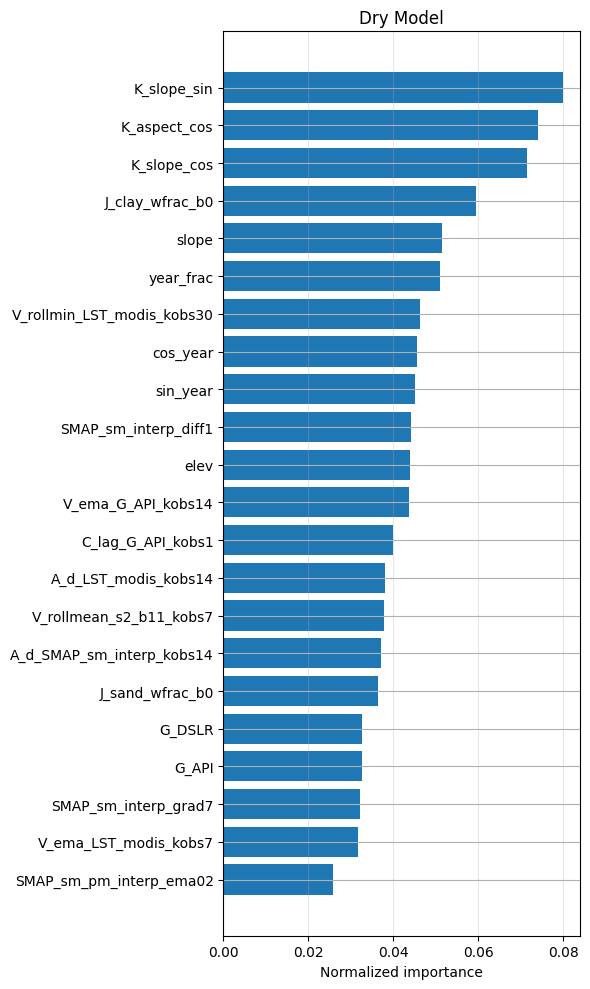

In [17]:
plot_top_features(dry_model, FEATURE_COLS_DRY, "Dry Model")

### Wet Model

In [18]:
XGB_PARAMS_WET = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=4,
    min_child_weight=8,
    subsample=0.9,
    colsample_bytree=0.8,
    n_estimators=2500,
    learning_rate=0.03,
    reg_lambda=1.5,
    reg_alpha=0.0,
)

X_train_wet_regime = X_train_wet.loc[mask_train_wet].copy()
X_val_wet_regime   = X_val_wet.loc[mask_val_wet].copy()
X_test_wet_regime  = X_test_wet.loc[mask_test_wet].copy()

y_train_wet = y_train.loc[mask_train_wet].copy()
y_val_wet   = y_val.loc[mask_val_wet].copy()
y_test_wet  = y_test.loc[mask_test_wet].copy()

wet_baseline = float(np.median(y_train_wet))

y_train_wet_res = y_train_wet - wet_baseline
y_val_wet_res   = y_val_wet - wet_baseline
y_test_wet_res  = y_test_wet - wet_baseline

wet_model = xgb.XGBRegressor(**XGB_PARAMS_WET)

wet_model.fit(
    X_train_wet_regime,
    y_train_wet_res,
    eval_set=[(X_val_wet_regime, y_val_wet_res)],
    verbose=False,
)

pred_wet_train = wet_model.predict(X_train_wet_regime) + wet_baseline
pred_wet_val   = wet_model.predict(X_val_wet_regime) + wet_baseline
pred_wet_test  = wet_model.predict(X_test_wet_regime) + wet_baseline

print("Wet expert trained")
print("  baseline:", wet_baseline)
print("  train:", X_train_wet_regime.shape)
print("  val:  ", X_val_wet_regime.shape)
print("  test: ", X_test_wet_regime.shape)

Wet expert trained
  baseline: 0.334
  train: (847, 28)
  val:   (576, 28)
  test:  (492, 28)



Wet Model - Top 25 Features
elev                           0.193235
slope                          0.186526
year_frac                      0.099259
V_rollstd_E_SAR_diff_kobs7     0.055808
A_d_E_SAR_diff_kobs7           0.049810
SMAP_sm_interp_rollrange7      0.047213
sin_year                       0.040083
A_grad_E_SAR_diff_kobs7        0.039361
A_grad_SMAP_sm_interp_kobs7    0.034419
A_d_SMAP_sm_interp_kobs7       0.031194
SMAP_sm_interp_lag7            0.026640
cos_year                       0.019878
A_d_F_NDMI_kobs7               0.017551
G_rain_sum_3d                  0.015986
A_grad_E_SAR_ratio_kobs7       0.014167
G_rain_sum_7d                  0.012621
SMAP_sm_interp_diff1           0.012310
A_d_E_SAR_diff_kobs1           0.012148
G_API                          0.011999
SMAP_sm_interp_rollstd7        0.010970
G_rain_sum_30d                 0.010872
V_rollstd_F_NDMI_kobs7         0.010420
V_rollstd_E_SAR_ratio_kobs7    0.009696
SMAP_sm_interp_pctchg          0.008927
A_d_G_API_k

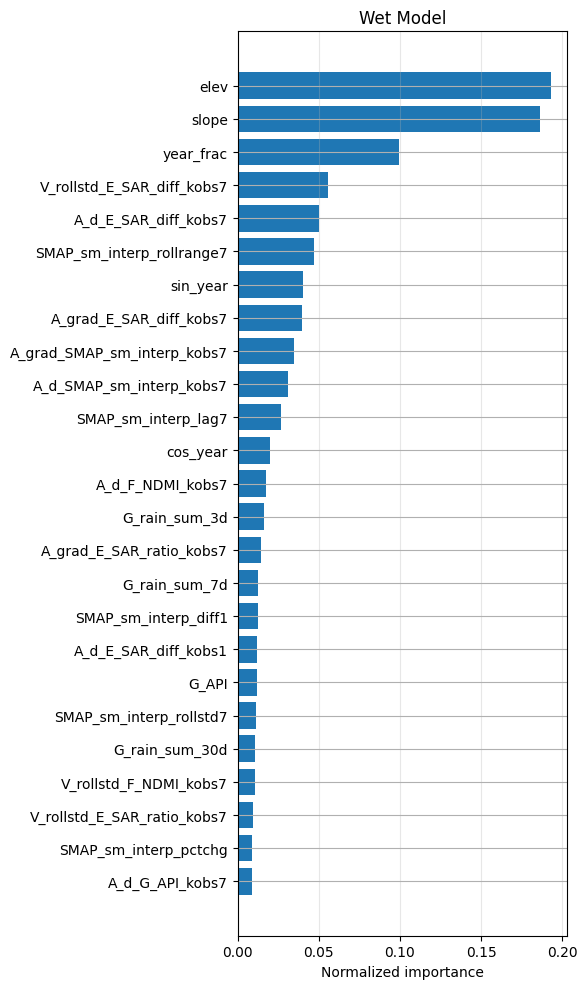

In [19]:
plot_top_features(wet_model, FEATURE_COLS_WET, "Wet Model")

### Transition Model

In [20]:
XGB_PARAMS_TRANSITION_RESID = dict(
    objective="reg:pseudohubererror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=4,
    min_child_weight=12,
    subsample=0.85,
    colsample_bytree=0.80,
    n_estimators=2500,
    learning_rate=0.02,
    reg_lambda=4.0,
    reg_alpha=0.10,
    gamma=0.0,
)

y_train_transition_resid = (
    y_train_transition - pred_train_transition_base
).copy()

y_val_transition_resid = (
    y_val_transition - pred_val_transition_base
).copy()

y_test_transition_resid = (
    y_test_transition - pred_test_transition_base
).copy()

transition_model = xgb.XGBRegressor(**XGB_PARAMS_TRANSITION_RESID)

transition_model.fit(
    X_train_transition_aug,
    y_train_transition_resid,
    eval_set=[(X_val_transition_aug, y_val_transition_resid)],
    verbose=False,
)

pred_transition_train_resid = pd.Series(
    transition_model.predict(X_train_transition_aug),
    index=X_train_transition_aug.index,
    name="pred_transition_train_resid",
)

pred_transition_val_resid = pd.Series(
    transition_model.predict(X_val_transition_aug),
    index=X_val_transition_aug.index,
    name="pred_transition_val_resid",
)

pred_transition_test_resid = pd.Series(
    transition_model.predict(X_test_transition_aug),
    index=X_test_transition_aug.index,
    name="pred_transition_test_resid",
)

pred_transition_train = (
    pred_train_transition_base + pred_transition_train_resid
).copy()

pred_transition_val = (
    pred_val_transition_base + pred_transition_val_resid
).copy()

pred_transition_test = (
    pred_test_transition_base + pred_transition_test_resid
).copy()

print("Transition residual expert trained")
print("  train residual mean abs:", np.mean(np.abs(y_train_transition_resid)))
print("  val residual mean abs:  ", np.mean(np.abs(y_val_transition_resid)))
print("  test residual mean abs: ", np.mean(np.abs(y_test_transition_resid)))

print("\nPrediction ranges")
print("  base val:  ", float(pred_val_transition_base.min()), "to", float(pred_val_transition_base.max()))
print("  final val: ", float(pred_transition_val.min()), "to", float(pred_transition_val.max()))
print("  base test: ", float(pred_test_transition_base.min()), "to", float(pred_test_transition_base.max()))
print("  final test:", float(pred_transition_test.min()), "to", float(pred_transition_test.max()))

Transition residual expert trained
  train residual mean abs: 0.008674000391872294
  val residual mean abs:   0.02163289472754645
  test residual mean abs:  0.028085741363252915

Prediction ranges
  base val:   0.12009244412183762 to 0.3316129446029663
  final val:  0.13653472065925598 to 0.3193802237510681
  base test:  0.13377559185028076 to 0.33058008551597595
  final test: 0.15758010745048523 to 0.3189361095428467



Transition Residual Expert - Top 25 Features
pred_dist_t2                  0.114021
J_clay_wfrac_b0               0.056049
J_sand_wfrac_b0               0.054781
pred_pos_raw                  0.043117
elev                          0.038712
pred_centered                 0.035202
pred_dist_t1                  0.034687
slope                         0.031680
A_d_LST_modis_kobs14          0.021988
SMAP_sm_interp_lag1           0.021486
SMAP_x_year                   0.020748
API_accel_3                   0.019250
G_rain_sum_3d                 0.018997
pred_centered_sq              0.018389
tr_api_x_slope                0.018161
A_d_G_API_kobs7               0.017115
SMAP_sm_interp_rollmean7      0.017102
V_ema_G_API_kobs7             0.016396
API_x_year                    0.016336
V_ema_LST_modis_kobs7         0.016310
V_rollmean_s2_b11_kobs7       0.015916
V_rollmin_LST_modis_kobs30    0.015491
API_saturation                0.015480
SMAP_x_API                    0.015289
V_rollmean_G_API_k

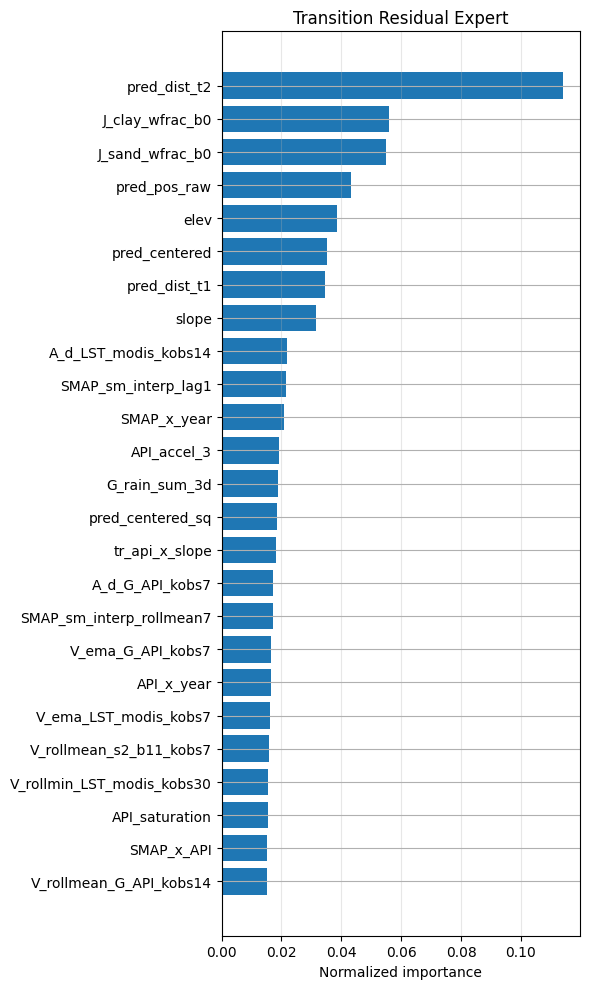

In [21]:
FEATURE_COLS_TRANSITION_AUG = list(X_train_transition_aug.columns)
plot_top_features(
    transition_model,
    FEATURE_COLS_TRANSITION_AUG,
    "Transition Residual Expert"
)

In [22]:
metrics_dashboard(
    y_val_dry,
    pred_dry_val,
    name="DRY EXPERT ON DRY VAL ROWS",
    return_dict=False
)

metrics_dashboard(
    y_val_transition,
    pred_transition_val,
    name="TRANSITION REGIME (VAL) | RESIDUAL EXPERT",
    return_dict=False,
)

metrics_dashboard(
    y_val_wet,
    pred_wet_val,
    name="WET EXPERT ON WET VAL ROWS",
    return_dict=False
)

In [23]:
metrics_dashboard(
    y_test_dry,
    pred_dry_test,
    name="DRY EXPERT ON DRY TEST ROWS",
    return_dict=False
)

metrics_dashboard(
    y_test_transition,
    pred_transition_test,
    name="TRANSITION REGIME (TEST) | RESIDUAL EXPERT",
    return_dict=False,
)

metrics_dashboard(
    y_test_wet,
    pred_wet_test,
    name="WET EXPERT ON WET TEST ROWS",
    return_dict=False
)

In [24]:
neat_print(
    get_metrics_dict(y_val_dry, pred_dry_val, prefix=""),
    "DRY REGIME (VAL)"
)

neat_print(
    get_metrics_dict(y_val_wet, pred_wet_val, prefix=""),
    "WET REGIME (VAL)"
)

neat_print(
    get_metrics_dict(y_val_transition, pred_transition_val, prefix=""),
    "TRANSITION REGIME (VAL)"
)

neat_print(
    get_metrics_dict(y_test_dry, pred_dry_test, prefix=""),
    "DRY REGIME (TEST)"
)

neat_print(
    get_metrics_dict(y_test_wet, pred_wet_test, prefix=""),
    "WET REGIME (TEST)"
)

neat_print(
    get_metrics_dict(y_test_transition, pred_transition_test, prefix=""),
    "TRANSITION REGIME (TEST)"
)


DRY REGIME (VAL)
Metric                          Value
------------------------------------------
n                                 988
r2                            0.55660
mae                           0.02252
rmse                          0.03059
ubrmse                        0.03036
bias                          0.00381
med_ae                        0.01706
p90_ae                        0.04763
q05_err                      -0.03859
q50_err                       0.00149
q95_err                       0.05534

WET REGIME (VAL)
Metric                          Value
------------------------------------------
n                                 576
r2                           -0.32687
mae                           0.01725
rmse                          0.02380
ubrmse                        0.02156
bias                          0.01009
med_ae                        0.01261
p90_ae                        0.03738
q05_err                      -0.01805
q50_err                       0.00671
q95_

In [25]:
w1 = 0.05
w2 = 0.12

def soft_weights_asym(signal, t1, t2, w1, w2):
    signal = np.asarray(signal, dtype=float)
    w_dry        = np.zeros_like(signal)
    w_transition = np.zeros_like(signal)
    w_wet        = np.zeros_like(signal)
    for i, s in enumerate(signal):
        if s <= t1 - w1:
            w_dry[i] = 1.0
        elif s < t1 + w1:
            alpha = (s - (t1 - w1)) / (2 * w1)
            w_dry[i]        = 1.0 - alpha
            w_transition[i] = alpha
        elif s <= t2 - w2:
            w_transition[i] = 1.0
        elif s < t2 + w2:
            alpha = (s - (t2 - w2)) / (2 * w2)
            w_transition[i] = 1.0 - alpha
            w_wet[i]        = alpha
        else:
            w_wet[i] = 1.0
    return w_dry, w_transition, w_wet

y_val_g  = y_val_full.copy()
y_test_g = y_test_full.copy()

reg_val_g  = assign_regime(y_val_g,  T1, T2)
reg_test_g = assign_regime(y_test_g, T1, T2)

mask_val_dry_g  = y_val_g.index[reg_val_g  == 0]
mask_val_tr_g   = y_val_g.index[reg_val_g  == 1]
mask_val_wet_g  = y_val_g.index[reg_val_g  == 2]

mask_test_dry_g = y_test_g.index[reg_test_g == 0]
mask_test_tr_g  = y_test_g.index[reg_test_g == 1]
mask_test_wet_g = y_test_g.index[reg_test_g == 2]

pred_dry_val_full = pd.Series(np.nan, index=y_val_g.index)
pred_wet_val_full = pd.Series(np.nan, index=y_val_g.index)
pred_tr_val_full  = pd.Series(np.nan, index=y_val_g.index)

pred_dry_val_full.loc[mask_val_dry_g] = pred_dry_val   # numpy array, same length as mask
pred_wet_val_full.loc[mask_val_wet_g] = pred_wet_val
pred_tr_val_full.update(pred_transition_val)            # Series with its own filtered index

pred_dry_test_full = pd.Series(np.nan, index=y_test_g.index)
pred_wet_test_full = pd.Series(np.nan, index=y_test_g.index)
pred_tr_test_full  = pd.Series(np.nan, index=y_test_g.index)

pred_dry_test_full.loc[mask_test_dry_g] = pred_dry_test
pred_wet_test_full.loc[mask_test_wet_g] = pred_wet_test
pred_tr_test_full.update(pred_transition_test)

w_dry_val, w_tr_val, w_wet_val    = soft_weights_asym(pred_val_base.values,  T1, T2, w1, w2)
w_dry_test, w_tr_test, w_wet_test = soft_weights_asym(pred_test_base.values, T1, T2, w1, w2)

pred_val_combined = (
    w_dry_val  * pred_dry_val_full.fillna(0).values +
    w_tr_val   * pred_tr_val_full.fillna(0).values  +
    w_wet_val  * pred_wet_val_full.fillna(0).values
)
pred_test_combined = (
    w_dry_test * pred_dry_test_full.fillna(0).values +
    w_tr_test  * pred_tr_test_full.fillna(0).values  +
    w_wet_test * pred_wet_test_full.fillna(0).values
)

val_keep  = np.isfinite(pred_val_combined)
test_keep = np.isfinite(pred_test_combined)

print(f"VAL  rows evaluated: {val_keep.sum()} / {len(y_val_g)}  (dropped: {(~val_keep).sum()})")
print(f"TEST rows evaluated: {test_keep.sum()} / {len(y_test_g)}  (dropped: {(~test_keep).sum()})")

VAL  rows evaluated: 2720 / 2720  (dropped: 0)
TEST rows evaluated: 4016 / 4016  (dropped: 0)


In [26]:
metrics_dashboard(
    y_val.values[val_keep],
    pred_val_combined[val_keep],
    name=f"COMBINED MODEL - VAL (soft gating, w1={w1}, w2={w2})",
    return_dict=False,
)

metrics_dashboard(
    y_test.values[test_keep],
    pred_test_combined[test_keep],
    name=f"COMBINED MODEL - TEST (soft gating, w1={w1}, w2={w2})",
    return_dict=False,
)

In [27]:
neat_print(
    get_metrics_dict(y_val.values[val_keep],   pred_val_combined[val_keep],  prefix=""),
    f"COMBINED MODEL - VAL  (w1={w1}, w2={w2})"
)
neat_print(
    get_metrics_dict(y_test.values[test_keep], pred_test_combined[test_keep], prefix=""),
    f"COMBINED MODEL - TEST (w1={w1}, w2={w2})"
)


COMBINED MODEL - VAL  (w1=0.05, w2=0.12)
Metric                          Value
------------------------------------------
n                               2,720
r2                           -0.22165
mae                           0.09219
rmse                          0.11614
ubrmse                        0.07748
bias                          0.08652
med_ae                        0.08735
p90_ae                        0.19654
q05_err                      -0.02319
q50_err                       0.08735
q95_err                       0.21549

COMBINED MODEL - TEST (w1=0.05, w2=0.12)
Metric                          Value
------------------------------------------
n                               4,016
r2                           -0.59398
mae                           0.09444
rmse                          0.11888
ubrmse                        0.07833
bias                          0.08943
med_ae                        0.08410
p90_ae                        0.20900
q05_err                      -0.

In [28]:
print("pred_dry_val_full  mean:", np.nanmean(pred_dry_val_full))
print("pred_wet_val_full  mean:", np.nanmean(pred_wet_val_full))
print("pred_tr_val_full   mean:", np.nanmean(pred_tr_val_full))
print("pred_val_base      mean:", pred_val_base.mean())
print("y_val_g            mean:", y_val_g.mean())

pred_dry_val_full  mean: 0.09134539891682897
pred_wet_val_full  mean: 0.3310911537975901
pred_tr_val_full   mean: 0.2576611078373289
pred_val_base      mean: 0.21309711
y_val_g            mean: 0.22149264705882354


---

_Jakob Balkovec_